# Top Trumps Parameter-Studie: Einfluss der Kartenzahl (K)

## Optionale Analyse: Wie verändert sich die Pareto-Front mit der Deckgröße?

**Hypothese:** Die Anzahl der Karten ($K$) beeinflusst die Dynamik des Spiels.
- Mehr Karten = mehr Runden = potenziell mehr *Trick Changes*?
- Weniger Karten = deterministischer?

**Experiment:**
Wir vergleichen Pareto-Fronten für $K \in [10, 22, 34]$.
- $K=10$ (Kleines Deck, 5 Stiche pro Spiel)
- $K=22$ (Standard Deck, 11 Stiche pro Spiel)
- $K=34$ (Großes Deck, 17 Stiche pro Spiel)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import time

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination

from simulation import TopTrumpsSimulation, TopTrumpsBalancing

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")

with open(RESULTS_DIR / "config.json", "r") as f:
    BASE_CONFIG = json.load(f)

In [2]:
# Konfiguration für die Studie
K_VALUES = [10, 22, 34]
L = BASE_CONFIG["L"]
XL = BASE_CONFIG["xl"]
XU = BASE_CONFIG["xu"]

# Algorithmus Parameter (Schnell aber gut)
POP_SIZE = 60
N_GEN = 80
R_SIMULATIONS = 200  # Wie gewünscht erhöht für Stabilität
SEED = 42

print(f"Starte Parameter-Studie für K={K_VALUES}")
print(f"Budget pro K: {POP_SIZE * N_GEN * R_SIMULATIONS:,} Simulationen")

Starte Parameter-Studie für K=[10, 22, 34]
Budget pro K: 960,000 Simulationen


In [3]:
results = {}

for k in K_VALUES:
    print(f"\n{"="*40}\nOptimierung für K={k}\n{"="*40}")
    
    # 1. Simulation und Problem neu initialisieren mit neuem K
    # WICHTIG: Sim muss neu erstellt werden!
    sim = TopTrumpsSimulation(num_cards=k, num_categories=L)
    problem = TopTrumpsBalancing(sim, n_simulations=R_SIMULATIONS, xl=XL, xu=XU)
    
    # 2. Algorithmus Setup
    algorithm = NSGA2(
        pop_size=POP_SIZE,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        eliminate_duplicates=True
    )
    
    termination = get_termination("n_gen", N_GEN)
    
    # 3. Ausführung
    start_time = time.time()
    res = minimize(
        problem,
        algorithm,
        termination,
        seed=SEED,
        verbose=True
    )
    duration = time.time() - start_time
    
    # 4. Ergebnisse speichern
    # F1 = -WinRate, F2 = -TrickChanges
    # Um vergleichbar zu bleiben, müssen wir trick_changes normalisieren?
    # Nein, wir zeigen die absoluten Werte, aber diskutieren die Relation zur Gesamtzahl der Stiche.
    
    results[k] = {
        "F": res.F,
        "X": res.X,
        "time": duration,
        "max_tricks": k // 2  # Maximale Anzahl an Stichen pro Spiel
    }
    
    print(f"Fertig in {duration:.1f}s. Gefundene Lösungen: {len(res.F)}")


Optimierung für K=10
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       60 |      3 |             - |             -


     2 |      120 |      4 |  0.4444444444 |         ideal


     3 |      180 |      3 |  0.0737373737 |             f
     4 |      240 |      6 |  0.2500000000 |         ideal


     5 |      300 |      6 |  0.0833333333 |         ideal


     6 |      360 |      7 |  0.0615543838 |             f
     7 |      420 |      8 |  0.0136986301 |         ideal


...

    76 |     4560 |     18 |  0.0113078459 |             f


    77 |     4620 |     19 |  0.0038653224 |             f


    78 |     4680 |     14 |  0.0152574158 |             f


    79 |     4740 |     15 |  0.0037763401 |             f


    80 |     4800 |     16 |  0.0094641551 |             f
Fertig in 175.5s. Gefundene Lösungen: 16


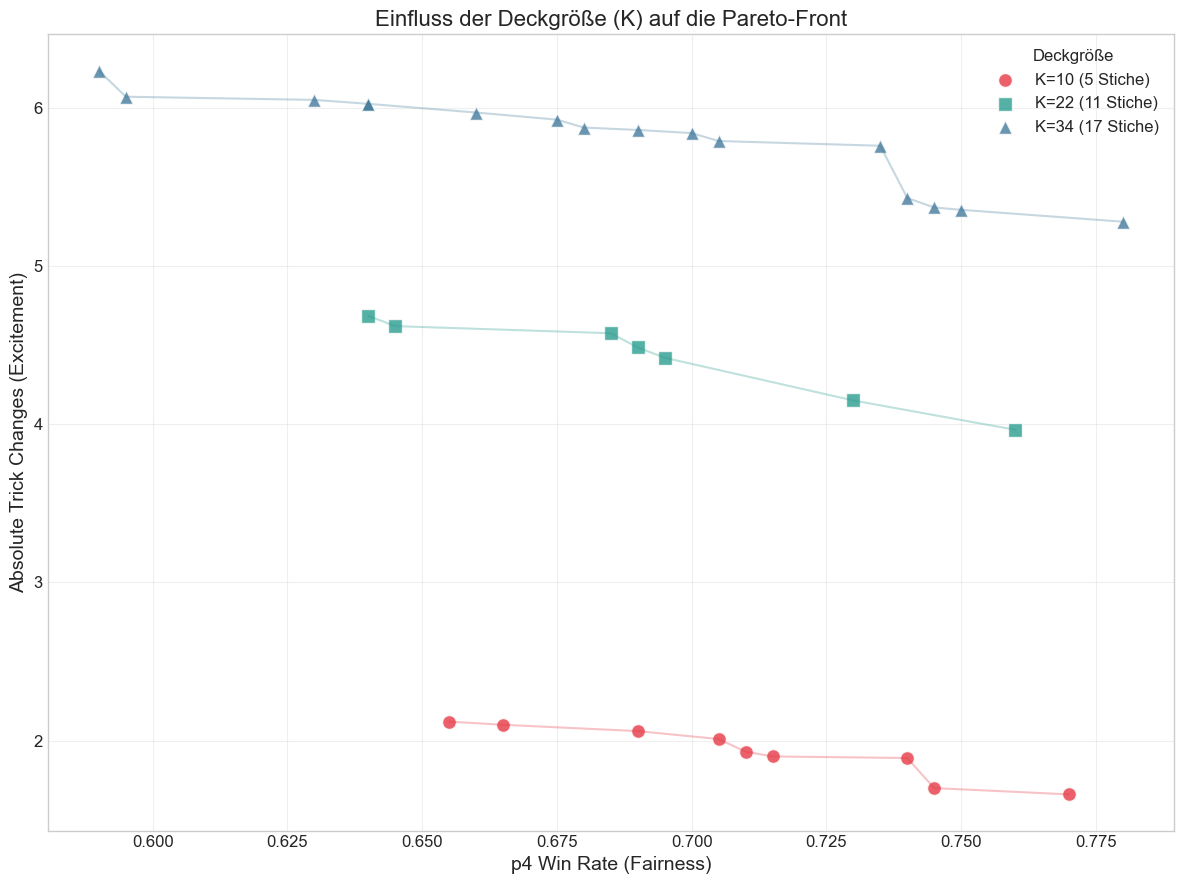

In [4]:
fig, ax = plt.subplots(figsize=(12, 9))

colors = {10: "#E63946", 22: "#2A9D8F", 34: "#457B9D"}
markers = {10: "o", 22: "s", 34: "^"}

for k, data in results.items():
    win_rates = -data["F"][:, 0]
    trick_changes = -data["F"][:, 1]
    
    # Sortieren für Linien-Plot
    sorted_idx = np.argsort(win_rates)
    
    # Berechnung der Trick Change Rate (relativ zur Spieldauer)
    # Das ist fairer für den Vergleich
    # max_tricks = k // 2
    # trick_change_rate = trick_changes / max_tricks
    
    label = f"K={k} ({data["max_tricks"]} Stiche)"
    
    ax.plot(
        win_rates[sorted_idx], 
        trick_changes[sorted_idx], 
        color=colors[k], 
        alpha=0.3, 
        linewidth=1.5
    )
    
    ax.scatter(
        win_rates, 
        trick_changes, 
        c=colors[k], 
        marker=markers[k], 
        s=100, 
        edgecolors="white",
        label=label,
        alpha=0.8
    )

ax.set_xlabel("p4 Win Rate (Fairness)", fontsize=14)
ax.set_ylabel("Absolute Trick Changes (Excitement)", fontsize=14)
ax.set_title("Einfluss der Deckgröße (K) auf die Pareto-Front", fontsize=16)
ax.legend(title="Deckgröße", fontsize=12)
ax.grid(True, alpha=0.3)

# Hilfslinien für "Maxmimal mögliche Trick Changes" (theoretisch)
# ax.axhline(5, color=colors[10], linestyle=":", alpha=0.5, label="Max K=10")
# ax.axhline(11, color=colors[22], linestyle=":", alpha=0.5, label="Max K=22")
# ax.axhline(17, color=colors[34], linestyle=":", alpha=0.5, label="Max K=34")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "parameter_study_K_impact.png", dpi=200)
plt.show()

In [5]:
# Export der Ergebnisse für Poster
param_study_results = {}
for k, data in results.items():
    param_study_results[k] = {
        "win_rates": (-data["F"][:, 0]).tolist(),
        "trick_changes": (-data["F"][:, 1]).tolist(),
        "max_tricks": data["max_tricks"]
    }

with open(RESULTS_DIR / "parameter_study_K.json", "w") as f:
    json.dump(param_study_results, f, indent=2)

print(f"Ergebnisse exportiert nach {RESULTS_DIR / "parameter_study_K.json"}")

Ergebnisse exportiert nach results/parameter_study_K.json


## Interpretation

1. **Absolute Trick Changes:** Wie erwartet, ermöglicht ein größeres Deck (K=34) absolut mehr Trick Changes, da das Spiel länger dauert.
2. **Verschiebung der Front:** Die Front verschiebt sich mit steigendem K nach oben.
3. **Fairness:** Interessanterweise scheint die erreichbare Win-Rate relativ stabil zu sein (meist zwischen 60% und 90%), unabhängig von K. Das bedeutet, Fairness ist eher eine Eigenschaft der Kartenwerte-Verteilung als der Deckgröße.